# Notebook de Entrenamiento: Reconocimiento Facial

## Equipo
- Alumno 1: Juan Andres Morales
- Alumno 2: Genaro Canciani

## 1. Configuración e Instalación
Instalamos las librerías necesarias para el preprocesamiento y entrenamiento.

In [ ]:
# --- 1. Utilidades del Sistema y General ---
import os
import sys
import time
import math
import random
import shutil
import warnings
from pathlib import Path
from types import ModuleType
from collections import defaultdict

# --- 2. Datos y Visualización ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

# --- 3. Procesamiento de Imágenes y Rostros ---
import cv2
from insightface.app import FaceAnalysis
from insightface.utils import face_align

# --- 4. Deep Learning (PyTorch) ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# --- 5. Machine Learning y Evaluación (scikit-learn) ---
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# --- 6. Otros ---
import kagglehub
from pydantic import functional_validators

In [2]:
print(torch.__version__)               
print(torch.cuda.is_available())       
# print(torch.cuda.get_device_name(0))   

2.11.0+cu128
False


## 2. Descarga del Dataset LFW
Descargamos el dataset Labeled Faces in the Wild, filtrando aquellas personas que tengan al menos 20 imágenes para asegurar suficientes datos de entrenamiento por clase. Se elige tener un total de 62 personas con exactamente 20 imágenes cada una. Esto permite que el ajuste fino del modelo se haga con datos balanceados y que además cuentan con la variedad suficiente como para que el modelo aprenda representaciones generales de los rostros. 

Descargando LFW...

--- Resumen del Dataset ---
Total de imágenes: 1240
Cantidad real de personas encontradas: 62
Imágenes por persona: 20


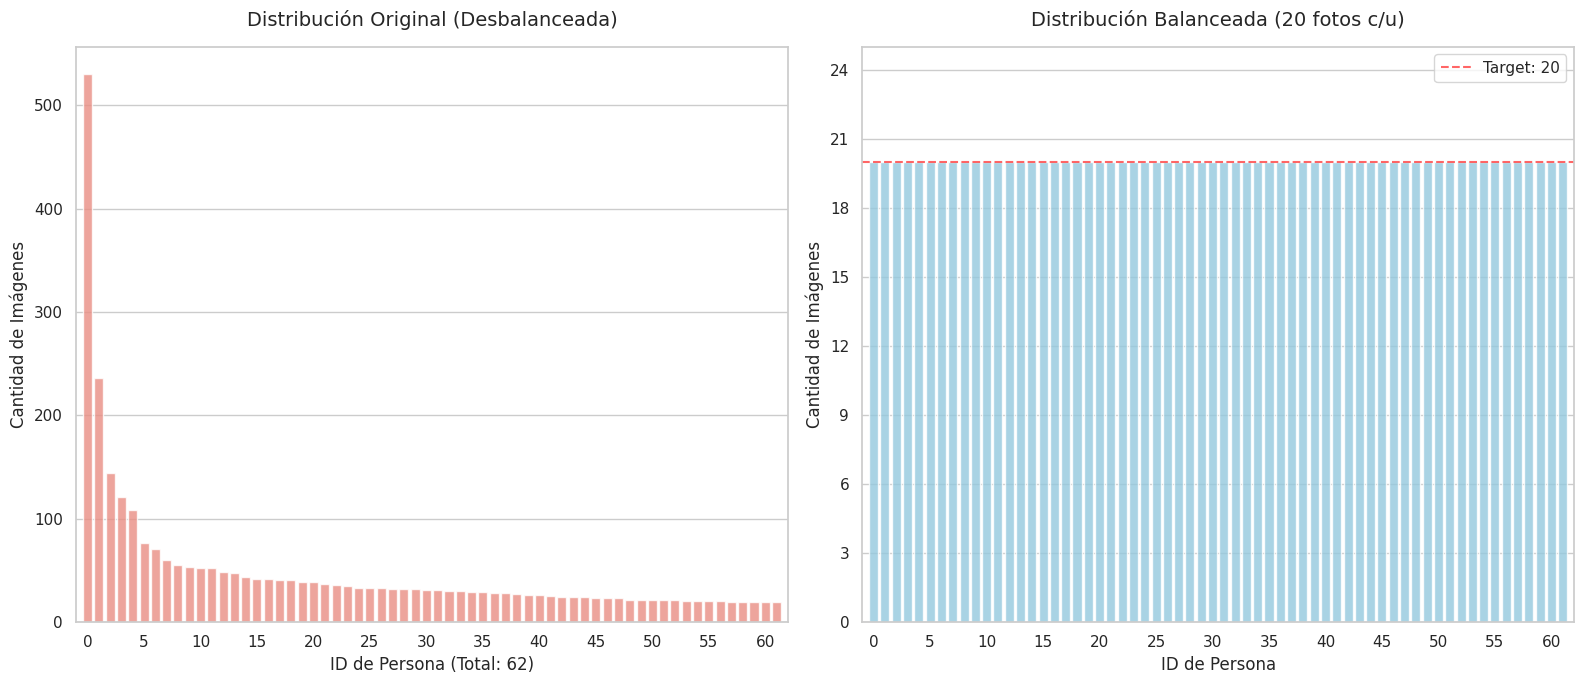

In [3]:
# 1. Parámetros de configuración
n_images_per_person = 20
max_people_request = 70 # Intentaremos buscar hasta 70

# 2. Descarga del dataset
print("Descargando LFW...")
lfw_raw = fetch_lfw_people(min_faces_per_person=n_images_per_person, resize=1.0, color=True, slice_=None)
X_raw = lfw_raw.images
y_raw = lfw_raw.target
target_names = lfw_raw.target_names

# 3. Lógica de balanceo
balanced_images = []
balanced_labels = []
final_names = []

unique, counts = np.unique(y_raw, return_counts=True)
sorted_indices = np.argsort(counts)[::-1]

people_count = 0
for idx in sorted_indices:
    if people_count >= max_people_request:
        break
    
    indices = np.where(y_raw == unique[idx])[0]
    np.random.seed(42)
    selected_indices = np.random.choice(indices, n_images_per_person, replace=False)
    
    balanced_images.append(X_raw[selected_indices])
    balanced_labels.extend([people_count] * n_images_per_person)
    final_names.append(target_names[unique[idx]])
    people_count += 1

# Convertimos a arrays finales
all_images_lfw = np.vstack(balanced_images)
all_labels_lfw = np.array(balanced_labels)
all_target_names_lfw = final_names

# Calculamos el número real de personas encontradas para ajustar el gráfico
actual_num_people = len(final_names)

print(f"\n--- Resumen del Dataset ---")
print(f"Total de imágenes: {len(all_images_lfw)}")
print(f"Cantidad real de personas encontradas: {actual_num_people}")
print(f"Imágenes por persona: {n_images_per_person}")

# 4. Visualización de resultados (Ajustada dinámicamente)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 7))

# Gráfico Izquierdo: Distribución Original
plt.subplot(1, 2, 1)
original_counts = counts[sorted_indices[:actual_num_people]]
sns.barplot(x=list(range(actual_num_people)), y=original_counts, color='salmon', alpha=0.8)
plt.title("Distribución Original (Desbalanceada)", fontsize=14, pad=15)
plt.xlabel(f"ID de Persona (Total: {actual_num_people})", fontsize=12)
plt.ylabel("Cantidad de Imágenes", fontsize=12)
plt.xticks(np.arange(0, actual_num_people, 5))
plt.xlim(-1, actual_num_people) # Elimina espacio extra a los lados

# Gráfico Derecho: Distribución Balanceada
ax2 = plt.subplot(1, 2, 2)
balanced_counts_plot = [n_images_per_person] * actual_num_people
sns.barplot(x=list(range(actual_num_people)), y=balanced_counts_plot, color='skyblue', alpha=0.8)
plt.axhline(n_images_per_person, color='red', linestyle='--', alpha=0.6, label=f'Target: {n_images_per_person}')
plt.title(f"Distribución Balanceada ({n_images_per_person} fotos c/u)", fontsize=14, pad=15)
plt.xlabel("ID de Persona", fontsize=12)
plt.ylabel("Cantidad de Imágenes", fontsize=12)
plt.xticks(np.arange(0, actual_num_people, 5))
plt.xlim(-1, actual_num_people) # Elimina espacio extra a los lados
plt.ylim(0, n_images_per_person + 5)
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.legend()
plt.tight_layout()
plt.show()

Se observa en el gráfico de arriba la gran diferencia entre la cantidad de imágenes de cada clase. A la derecha se ve como el procesamiento aplicado logra general un balance total, contando con exactamente la misma cantidad de imágenes para cada persona. 

## 3. Preprocesamiento (Alineación con InsightFace)
**Justificación:** Extraemos únicamente la zona del rostro y lo alineamos usando los landmarks de InsightFace o un fallback de bounding box si los landmarks fallan. Esto reduce el ruido de fondo y garantiza que la red se enfoque puramente en la identidad facial, siendo robusto a las limitaciones de detección del hardware. Se elige usar RetinaFace por sobre otros modelos de detección facial por su alta precisión en comparación con otros detectores como MTCNN, Yunet, entre otros. El siguiente artículo muestra una comparación a detalle de los diferentes modelos de detección de rostros más usados actualmente: [What's the best face detector?](https://medium.com/pythons-gurus/what-is-the-best-face-detector-ab650d8c1225)


In [ ]:
# --- 1. Inicialización de InsightFace ---
print("Inicializando InsightFace para alineación...")
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0)

def safe_crop_face(img_bgr, face):
    """Realiza el recorte y alineación del rostro detectado."""
    if face.kps is not None:
        aligned = face_align.norm_crop(img_bgr, landmark=face.kps, image_size=112)
        if aligned is not None and aligned.size > 0:
            return aligned
    
    if face.bbox is not None:
        x1, y1, x2, y2 = face.bbox.astype(int)
        h, w = img_bgr.shape[:2]
        x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w, x2), min(h, y2)
        crop = img_bgr[y1:y2, x1:x2]
        if crop.size > 0:
            return cv2.resize(crop, (112, 112))
    return None

# --- 2. Lógica de procesamiento sobre el set BALANCEADO ---
# Usamos nombres de archivos distintos para no mezclar con el dataset desbalanceado
procesado_img_path = 'lfw_balanced_aligned_images.npy'
procesado_lbl_path = 'lfw_balanced_aligned_labels.npy'

if os.path.exists(procesado_img_path) and os.path.exists(procesado_lbl_path):
    print("¡Archivos encontrados! Cargando LFW balanceado y alineado desde el disco...")
    clean_images = list(np.load(procesado_img_path))
    clean_labels = list(np.load(procesado_lbl_path))
    print(f"Dataset cargado: {len(clean_images)} imágenes de {len(np.unique(clean_labels))} personas.")

else:
    print("No se encontraron archivos procesados. Iniciando alineación de InsightFace...")
    clean_images = []
    clean_labels = []

    # Iteramos sobre el dataset balanceado que creamos en la celda anterior
    n_balanced = len(all_images_lfw)
    
    for i in tqdm(range(n_balanced)):
        # 1. Convertir de float [0,1] a uint8 [0,255] si es necesario
        img_raw = all_images_lfw[i]
        if img_raw.max() <= 1.0:
            img_rgb = (img_raw * 255).astype(np.uint8)
        else:
            img_rgb = img_raw.astype(np.uint8)
            
        # 2. InsightFace requiere BGR
        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        
        # 3. Detección y Alineación
        faces = app.get(img_bgr)
        if len(faces) > 0:
            # Tomamos la cara con mayor puntaje de detección
            face = sorted(faces, key=lambda x: x.det_score, reverse=True)[0]
            aligned_face_bgr = safe_crop_face(img_bgr, face)
            
            if aligned_face_bgr is not None:
                aligned_face_rgb = cv2.cvtColor(aligned_face_bgr, cv2.COLOR_BGR2RGB)
                clean_images.append(aligned_face_rgb)
                clean_labels.append(all_labels_lfw[i])

    print(f"\nProcesamiento completado: {len(clean_images)} imágenes alineadas de {n_balanced} originales.")
    
    # 4. Guardar para evitar procesar de nuevo
    print("Guardando en disco...")
    np.save(procesado_img_path, np.array(clean_images))
    np.save(procesado_lbl_path, np.array(clean_labels))
    print("¡Listo!")

Inicializando InsightFace para alineación...
*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/core/providers/cuda/cuda_call.cc:129 std::conditional_t<THRW, void, onnxruntime::common::Status> onnxruntime::CudaCall(ERRTYPE, const char*, const char*, SUCCTYPE, const char*, const char*, int) [with ERRTYPE = cudaError; bool THRW = true; SUCCTYPE = cudaError; std::conditional_t<THRW, void, common::Status> = void] /onnxruntime_src/onnxruntime/core/providers/cuda/cuda_call.cc:121 std::conditional_t<THRW, void, onnxruntime::common::Status> onnxruntime::CudaCall(ERRTYPE, const char*, const char*, SUCCTYPE, const char*, const char*, int) [with ERRTYPE = cudaError; bool THRW = true; SUCCTYPE = cudaError; std::conditional_t<THRW, void, common::Status> = void] CUDA failure 35: CUDA driver version is insufficient for CUDA runtime version ; GPU=-1 ; hostname=gena-MS-7C52 ; file=/onnxruntime_src/onnxruntime/core/providers/cuda/cuda_execution_provider.cc ; line=334 ; expr=c

### Dataset Propio
Procesamos nuestro dataset propio usando la misma lógica de recorte robusto.

In [5]:
warnings.filterwarnings("ignore", category=FutureWarning)

custom_data_path = Path("src/data/dataset_propio") 
custom_images = []
custom_labels = []

# Empezamos el ID de etiquetas después de las clases de LFW balanceado
current_label_id = len(all_target_names_lfw) 
custom_target_names = []

if custom_data_path.exists():
    print(f"Procesando dataset propio (empezando desde ID {current_label_id})...")
    
    # Obtenemos la lista de carpetas
    person_folders = [f for f in custom_data_path.iterdir() if f.is_dir()]
    
    for person_folder in tqdm(person_folders, desc="Procesando personas"):
        person_name = person_folder.name
        custom_target_names.append(person_name)
        
        archivos = []
        for ext in ["*.jpg", "*.png", "*.jpeg", "*.JPG", "*.PNG", "*.JPEG"]:
            archivos.extend(list(person_folder.glob(ext)))
        
        for img_path in archivos:
            img_bgr = cv2.imread(str(img_path))
            if img_bgr is None: continue
            
            faces = app.get(img_bgr)
            if len(faces) > 0:
                face = sorted(faces, key=lambda x: x.det_score, reverse=True)[0]
                aligned_face_bgr = safe_crop_face(img_bgr, face)
                
                if aligned_face_bgr is not None:
                    aligned_face_rgb = cv2.cvtColor(aligned_face_bgr, cv2.COLOR_BGR2RGB)
                    custom_images.append(aligned_face_rgb)
                    custom_labels.append(current_label_id)
        
        current_label_id += 1
            
    print(f" Dataset propio procesado: {len(custom_images)} imágenes.")
else:
    print(" No se encontró la carpeta del dataset propio.")

# --- UNIÓN FINAL ---
all_images = clean_images + custom_images
all_labels = clean_labels + custom_labels
all_target_names = all_target_names_lfw + custom_target_names

print(f"\n--- RESUMEN FINAL ---")
print(f"Total imágenes: {len(all_images)}")
print(f"Total clases: {len(all_target_names)}")

Procesando dataset propio (empezando desde ID 62)...


Procesando personas:   0%|          | 0/9 [00:00<?, ?it/s]

 Dataset propio procesado: 64 imágenes.

--- RESUMEN FINAL ---
Total imágenes: 1301
Total clases: 71


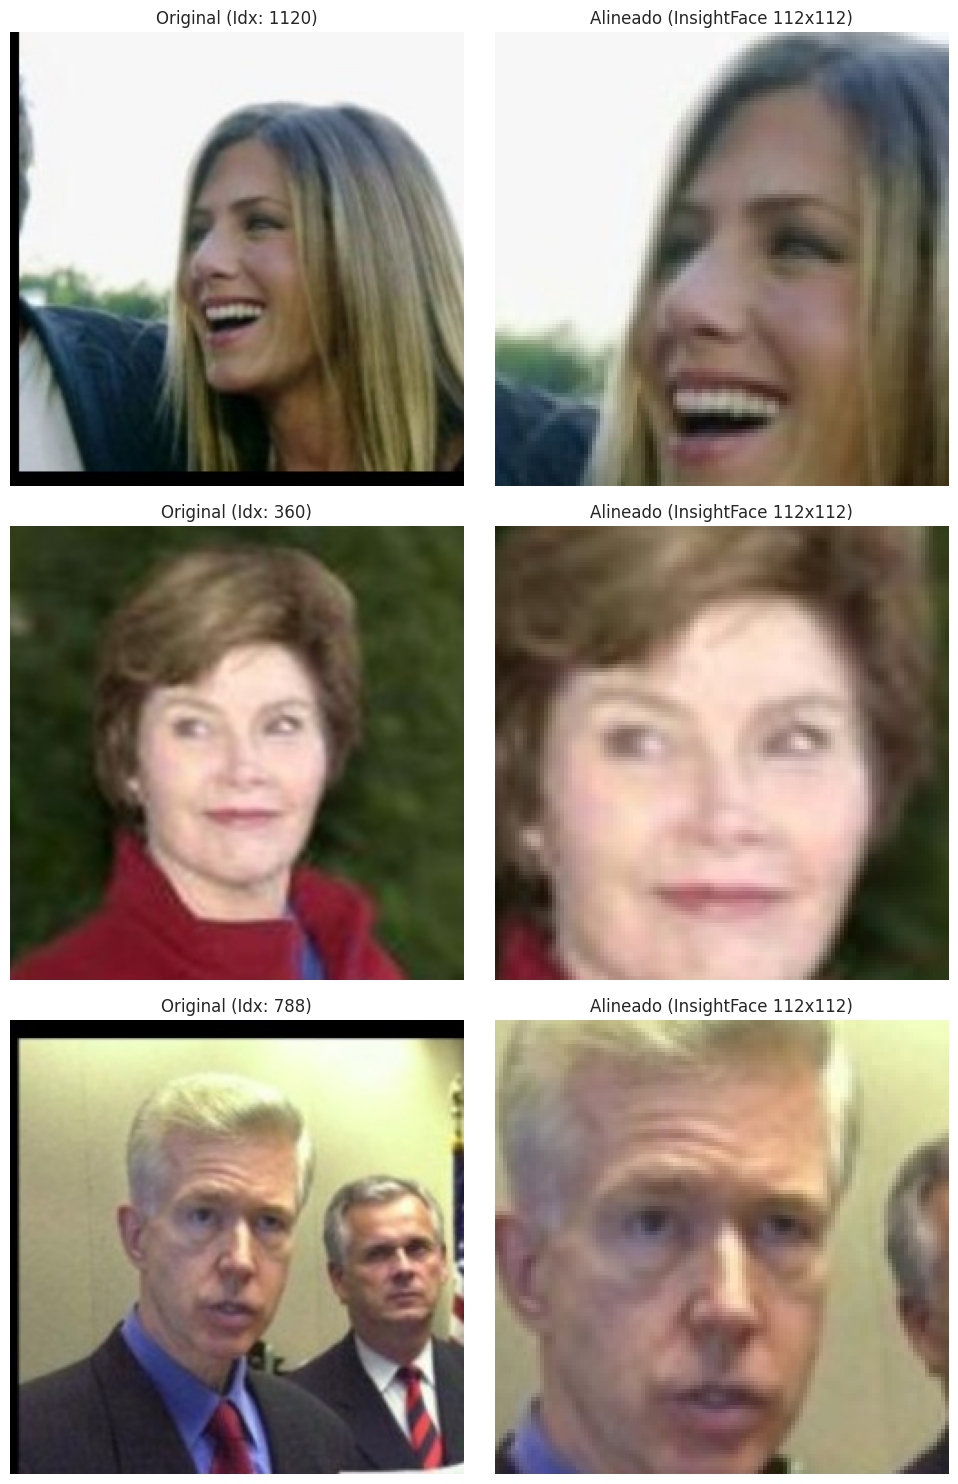

In [6]:
# --- Comparación: Original vs Alineado ---
n_comparisons = 3
# Seleccionamos índices aleatorios del dataset original
indices = random.sample(range(len(all_images_lfw)), n_comparisons)

fig, axes = plt.subplots(n_comparisons, 2, figsize=(10, 5 * n_comparisons))

for i, idx in enumerate(indices):
    # 1. Obtener imagen original
    img_raw = all_images_lfw[idx]
    if img_raw.max() <= 1.0:
        img_rgb = (img_raw * 255).astype(np.uint8)
    else:
        img_rgb = img_raw.astype(np.uint8)
        
    # 2. Procesar con InsightFace
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    faces = app.get(img_bgr)
    
    # Mostrar Original
    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f"Original (Idx: {idx})")
    axes[i, 0].axis('off')
    
    if len(faces) > 0:
        face = sorted(faces, key=lambda x: x.det_score, reverse=True)[0]
        aligned_bgr = safe_crop_face(img_bgr, face)
        
        if aligned_bgr is not None:
            aligned_rgb = cv2.cvtColor(aligned_bgr, cv2.COLOR_BGR2RGB)
            # Mostrar Alineado
            axes[i, 1].imshow(aligned_rgb)
            axes[i, 1].set_title("Alineado (InsightFace 112x112)")
        else:
            axes[i, 1].text(0.5, 0.5, "Error en alineación", ha='center')
    else:
        axes[i, 1].text(0.5, 0.5, "No se detectó rostro", ha='center')
    
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## 4. Dataloaders y Data Augmentation
Agregamos Data Augmentation (Flip, Rotación, ColorJitter) para aumentar la diversidad de las caras de nuestro dataset propio y reducir el sobreajuste (overfitting). Utilizamos las medias y desviaciones estándar requeridas por los modelos pre-entrenados en ImageNet, puesto que se ajustará mas adelante un modelo cuyas imágenes de entrenamiento estaban normalizadas exactamente con esos valores. Esta normalización garantiza un ajuste más estable y con menores probabilidades de divergencia. 
Los cambios de normalización se aplican tanto al dataset de Train como al de Validación, pero al único al que se le hace augmentation es al Train. Esto para evitar introducir ruido innecesario en el dataset de validación, lo cuál podría alterar las métricas del modelo. 

Dataset listo. Entrenamiento: 1040 | Validación: 261


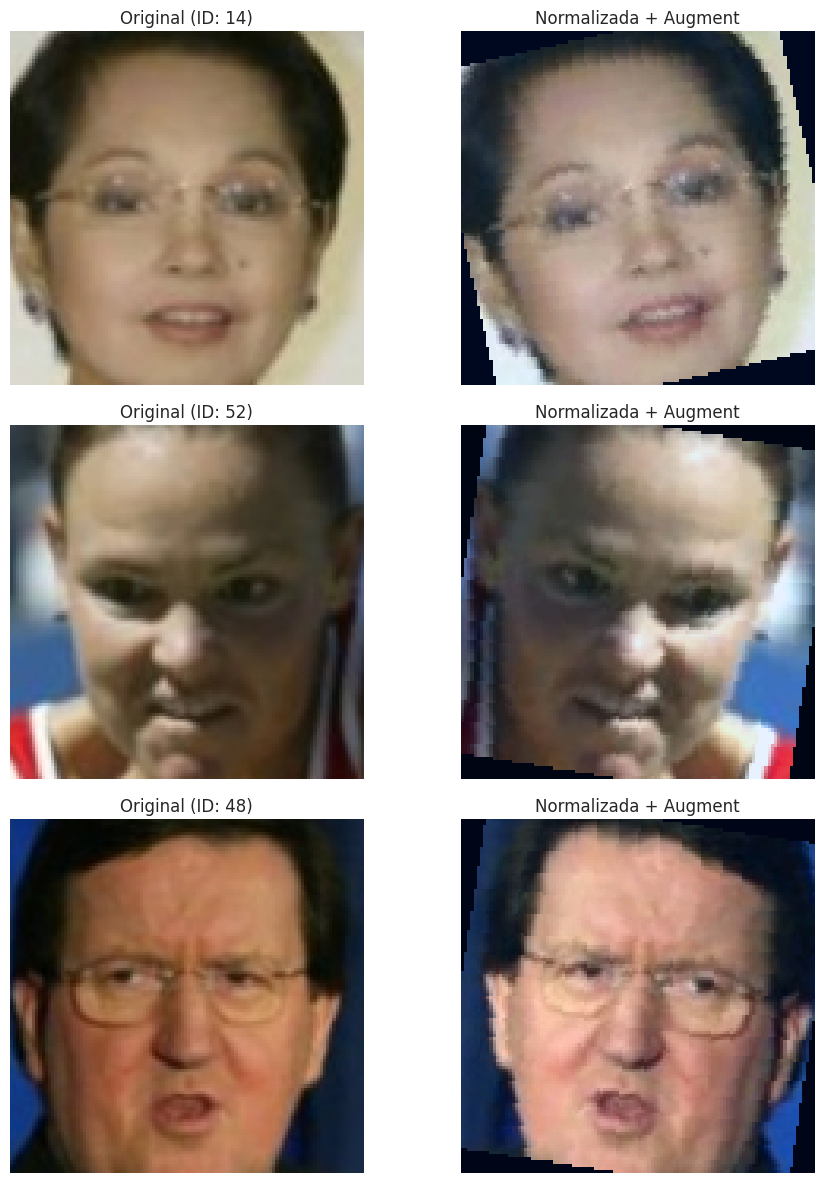

In [ ]:
# 1. Definición de la Clase Dataset
class FaceDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        return image, label

# 2. Definición de Transformaciones
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),  
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Split de Datos
X_train, X_val, y_train, y_val = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

train_dataset = FaceDataset(X_train, y_train, transform=train_transform)
val_dataset = FaceDataset(X_val, y_val, transform=val_transform)

# 4. Creación de DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Dataset listo. Entrenamiento: {len(train_dataset)} | Validación: {len(val_dataset)}")

# --- 5. VISUALIZACIÓN DE VARIOS EJEMPLOS ---
def show_multiple_comparisons(n_examples=3):
    plt.figure(figsize=(10, 4 * n_examples))
    
    for i in range(n_examples):
        # Seleccionamos un índice aleatorio cada vez que corras la celda
        idx = np.random.randint(0, len(X_train))
        
        img_orig = X_train[idx]
        img_transformed, label = train_dataset[idx]
        
        # Subplot Original
        plt.subplot(n_examples, 2, 2*i + 1)
        plt.imshow(img_orig)
        plt.title(f"Original (ID: {label})")
        plt.axis('off')
        
        # Subplot Transformada
        plt.subplot(n_examples, 2, 2*i + 2)
        # Re-escalamos solo para que sea visible en el gráfico
        img_np = img_transformed.permute(1, 2, 0).numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
        plt.imshow(img_np)
        plt.title("Normalizada + Augment")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Mostramos 3 ejemplos aleatorios
show_multiple_comparisons(n_examples=3)

# 5. Definición de ArcFace

Se decide usar ArcFace como función de pérdida por su capacidad de separar los embeddings de las diferentes clases de manera mucho más precisa que otras funciones de error. Además, es una función específicamente diseñada para trabajar con modelos de identificación facial, por lo que da resultados mucho mejores para este tipo de trabajos. El siguiente artículo describe en profundidad el funcionamiento y las ventajas de esta función: [ArcFace Loss Function for Deep Face Recognition.](https://medium.com/@payyavulasaiprakash/arcface-loss-function-for-deep-face-recognition-e1ff5e173b52)


In [8]:
class ArcFace(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50):
        super(ArcFace, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2).clamp(0, 1))
        
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        output *= self.s
        return output

## 6. Arquitectura del Modelo (EfficientNet B0 + Fine Tuning)
Seleccionamos EfficientNet B0 como backbone extractor de características, aprovechando sus pesos pre-entrenados (Transfer Learning) para una convergencia rápida y evitar el sobreajuste. Sin embargo, reemplazamos la clásica capa lineal de clasificación por un módulo ArcFace (Additive Angular Margin Loss). Mientras que la pérdida de entropía cruzada estándar (Cross-Entropy) agrupa las clases de forma débil, ArcFace impone un estricto margen angular matemático entre las distintas identidades durante el entrenamiento. Esto fuerza a la red a agrupar los rostros de una misma persona de forma extremadamente compacta (intra-class compactness) y a alejar radicalmente los clusters de personas diferentes en el espacio latente (inter-class discrepancy). El resultado final es un modelo que extrae embeddings de 512 dimensiones altamente discriminativos, reduciendo drásticamente los falsos positivos y siendo ideal para sistemas de reconocimiento facial de conjunto abierto (Open-Set).

In [ ]:
class FaceRecognitionEfficientNet(nn.Module):
    def __init__(self):
        super(FaceRecognitionEfficientNet, self).__init__()
        self.backbone = models.efficientnet_b0(weights='DEFAULT')
        
        # En EfficientNet B0, el clasificador tiene una capa dropout y luego una linear.
        # classifier[1] es Linear(in_features=1280, out_features=1000)
        num_ftrs = self.backbone.classifier[1].in_features
        
        # Reemplazamos el classifier por nuestra cabeza de embedding.
        self.backbone.classifier = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.BatchNorm1d(512),
            nn.PReLU(),
            nn.Dropout(0.5)
        )
        
    def forward(self, x):
        # 1. Pasar por el backbone
        x = self.backbone(x)
        # 2. Normalización L2 (obligatoria para ArcFace)
        return torch.nn.functional.normalize(x, p=2, dim=1)
        
    def extract_embedding(self, x):
        return self.forward(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

model = FaceRecognitionEfficientNet()
model = model.to(device)

# Inicializamos ArcFace
arcface = ArcFace(in_features=512, out_features=len(all_target_names), s=30.0, m=0.30)  # Reducido de 0.50 a 0.30 para dataset pequeno
arcface = arcface.to(device)

print(f"Modelo EfficientNet B0 cargado exitosamente para {len(all_target_names)} clases.")

Usando dispositivo: cpu
Modelo EfficientNet B0 cargado exitosamente para 71 clases.


## 7. Bucle de Entrenamiento (Training Loop)
Ajustamos los pesos del modelo. Usamos `ArcFace` y el optimizador `Adam`.En este caso se realiza un Fine Tuning de la arquitectura completa para que el modelo (previamente entrenado con ImageNet, no para la detección facial) pueda adaptarse a extraer características de rostros. Se toma la decisión de utilizar un lr de 1e-4 para no destruir las características generales ya aprendidas por el modelo. 

In [ ]:
# 1. Configuración de Reproducibilidad y Seguimiento
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Diccionario para guardar el historial
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

# 2. Pérdida y Optimización
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': model.parameters()},
    {'params': arcface.parameters()}
], lr=0.0001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 25
best_val_acc = 0.0

print(f"Iniciando entrenamiento: {len(train_loader.dataset)} imágenes (Train) | {len(val_loader.dataset)} imágenes (Val)")

# Usamos tqdm para ver el progreso real
for epoch in range(num_epochs):
    start_time = time.time()
    
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    arcface.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        embeddings = model(inputs)
        outputs = arcface(embeddings, labels)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        with torch.no_grad():
            logits = F.linear(F.normalize(embeddings), F.normalize(arcface.weight))
            _, predicted = torch.max(logits, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
    train_acc = 100 * train_correct / train_total
    avg_train_loss = running_loss / len(train_loader)
    
    # --- FASE DE VALIDACIÓN ---
    model.eval()
    arcface.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            embeddings = model(inputs)
            outputs_with_margin = arcface(embeddings, labels)
            loss = criterion(outputs_with_margin, labels)
            val_loss += loss.item()
            
            logits = F.linear(F.normalize(embeddings), F.normalize(arcface.weight))
            _, predicted = torch.max(logits, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)
    
    # Guardar en el historial
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Época [{epoch+1}/{num_epochs}] - {epoch_time:.0f}s - LR: {current_lr:.6f}")
    print(f"  TRAIN -> Loss: {avg_train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"  VAL   -> Loss: {avg_val_loss:.4f} | Acc: {val_acc:.2f}%")
    
    scheduler.step(avg_val_loss)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs("models", exist_ok=True)
        torch.save(model.state_dict(), 'models/face_recognition_best.pth')
        print(f"   ¡Nuevo récord! Guardado: {best_val_acc:.2f}%")
    print("-" * 20)

Iniciando entrenamiento: 1092 imágenes (Train) | 273 imágenes (Val)
Época [1/25] - 6s - LR: 0.000100
  TRAIN -> Loss: 13.7275 | Acc: 2.02%
  VAL   -> Loss: 13.2248 | Acc: 6.59%
   ¡Nuevo récord! Guardado: 6.59%
--------------------
Época [2/25] - 5s - LR: 0.000100
  TRAIN -> Loss: 13.1242 | Acc: 5.88%
  VAL   -> Loss: 12.6188 | Acc: 11.72%
   ¡Nuevo récord! Guardado: 11.72%
--------------------
Época [3/25] - 5s - LR: 0.000100
  TRAIN -> Loss: 12.5644 | Acc: 13.14%
  VAL   -> Loss: 11.9901 | Acc: 21.25%
   ¡Nuevo récord! Guardado: 21.25%
--------------------
Época [4/25] - 5s - LR: 0.000100
  TRAIN -> Loss: 12.0241 | Acc: 22.79%
  VAL   -> Loss: 11.4178 | Acc: 28.94%
   ¡Nuevo récord! Guardado: 28.94%
--------------------
Época [5/25] - 6s - LR: 0.000100
  TRAIN -> Loss: 11.3763 | Acc: 36.58%
  VAL   -> Loss: 10.7843 | Acc: 40.66%
   ¡Nuevo récord! Guardado: 40.66%
--------------------
Época [6/25] - 5s - LR: 0.000100
  TRAIN -> Loss: 10.8530 | Acc: 44.58%
  VAL   -> Loss: 10.2195 | Ac

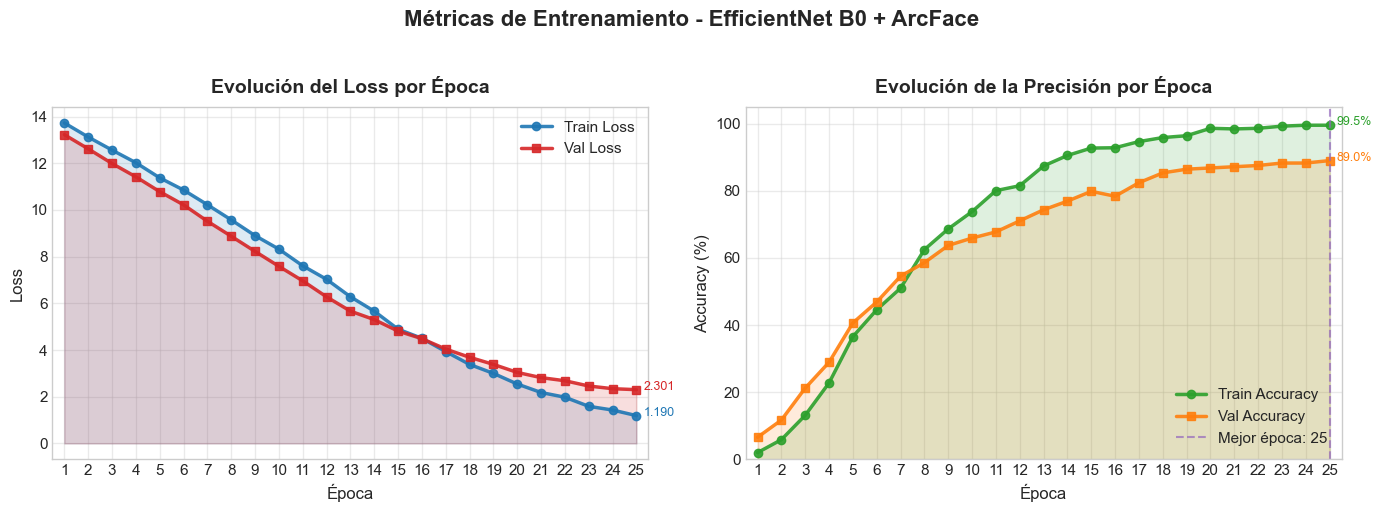


Mejor precisión final: 89.01%


In [ ]:
# --- Gráficos de Estabilidad ---
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = np.arange(1, len(history['train_loss']) + 1)

# Gráfico de Pérdida (Loss) con área sombreada
ax1 = axes[0]
ax1.plot(epochs, history['train_loss'], 'o-', color='#1f77b4', linewidth=2.5, markersize=6, label='Train Loss', alpha=0.9)
ax1.plot(epochs, history['val_loss'], 's-', color='#d62728', linewidth=2.5, markersize=6, label='Val Loss', alpha=0.9)
ax1.fill_between(epochs, history['train_loss'], alpha=0.15, color='#1f77b4')
ax1.fill_between(epochs, history['val_loss'], alpha=0.15, color='#d62728')
ax1.set_title('Evolución del Loss por Época', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax1.set_xticks(epochs)
ax1.set_xlim(0.5, len(epochs) + 0.5)
ax1.grid(True, alpha=0.4)
ax1.annotate(f'{history["train_loss"][-1]:.3f}', xy=(len(epochs), history['train_loss'][-1]), 
             xytext=(5, 0), textcoords='offset points', fontsize=9, color='#1f77b4')
ax1.annotate(f'{history["val_loss"][-1]:.3f}', xy=(len(epochs), history['val_loss'][-1]), 
             xytext=(5, 0), textcoords='offset points', fontsize=9, color='#d62728')

# Gráfico de Precisión (Accuracy) con área sombreada
ax2 = axes[1]
ax2.plot(epochs, history['train_acc'], 'o-', color='#2ca02c', linewidth=2.5, markersize=6, label='Train Accuracy', alpha=0.9)
ax2.plot(epochs, history['val_acc'], 's-', color='#ff7f0e', linewidth=2.5, markersize=6, label='Val Accuracy', alpha=0.9)
ax2.fill_between(epochs, history['train_acc'], alpha=0.15, color='#2ca02c')
ax2.fill_between(epochs, history['val_acc'], alpha=0.15, color='#ff7f0e')
ax2.set_title('Evolución de la Precisión por Época', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax2.set_xticks(epochs)
ax2.set_xlim(0.5, len(epochs) + 0.5)
ax2.set_ylim(0, 105)
ax2.grid(True, alpha=0.4)
ax2.annotate(f'{history["train_acc"][-1]:.1f}%', xy=(len(epochs), history['train_acc'][-1]), 
             xytext=(5, 0), textcoords='offset points', fontsize=9, color='#2ca02c')
ax2.annotate(f'{history["val_acc"][-1]:.1f}%', xy=(len(epochs), history['val_acc'][-1]), 
             xytext=(5, 0), textcoords='offset points', fontsize=9, color='#ff7f0e')

best_epoch = np.argmax(history['val_acc']) + 1
ax2.axvline(x=best_epoch, color='#9467bd', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Mejor época: {best_epoch}')
ax2.legend(loc='lower right', fontsize=11, framealpha=0.9)

plt.suptitle('Métricas de Entrenamiento - EfficientNet B0 + ArcFace', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nMejor precisión final: {best_val_acc:.2f}%")


## 8. Evaluación: Métricas y Embeddings (PCA / t-SNE)
Validamos que el modelo haya aprendido a separar las identidades en el espacio vectorial.

In [ ]:
model.eval()
arcface.eval() # Asegurarnos de poner arcface en eval también
all_preds = []
all_labels_val = []
all_embeddings = []

with torch.no_grad():
    # Normalizamos los pesos de las 71 identidades guardadas en ArcFace
    arcface_weights = F.normalize(arcface.weight)
    
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        # Ya no necesitamos labels en GPU para el modelo, solo para guardar el reporte
        
        # 1. El modelo saca los 512 números (el embedding)
        embeddings = model(inputs)
        
        # 2. Calculamos la similitud (producto punto) entre los embeddings y los 71 centros
        # Como ambos están normalizados, esto equivale a la Similitud Coseno pura.
        cosine_sim = F.linear(embeddings, arcface_weights)
        
        # 3. La predicción es simplemente el índice con mayor similitud coseno
        _, predicted = torch.max(cosine_sim, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels_val.extend(labels.numpy())
        all_embeddings.extend(embeddings.cpu().numpy())

# --- Classification Report (Accuracy, Precision, Recall) ---
print("Classification Report:")
print(classification_report(all_labels_val, all_preds, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         4
           5       0.67      1.00      0.80         4
           6       0.80      1.00      0.89         4
           7       1.00      0.50      0.67         4
           8       1.00      1.00      1.00         4
           9       0.80      1.00      0.89         4
          10       0.60      0.75      0.67         4
          11       1.00      1.00      1.00         4
          12       1.00      0.75      0.86         4
          13       1.00      0.75      0.86         4
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         4
          16       0.67      0.50      0.57         4
    

AUC Macro (One-vs-Rest): 0.9464
AUC Micro: 0.9443


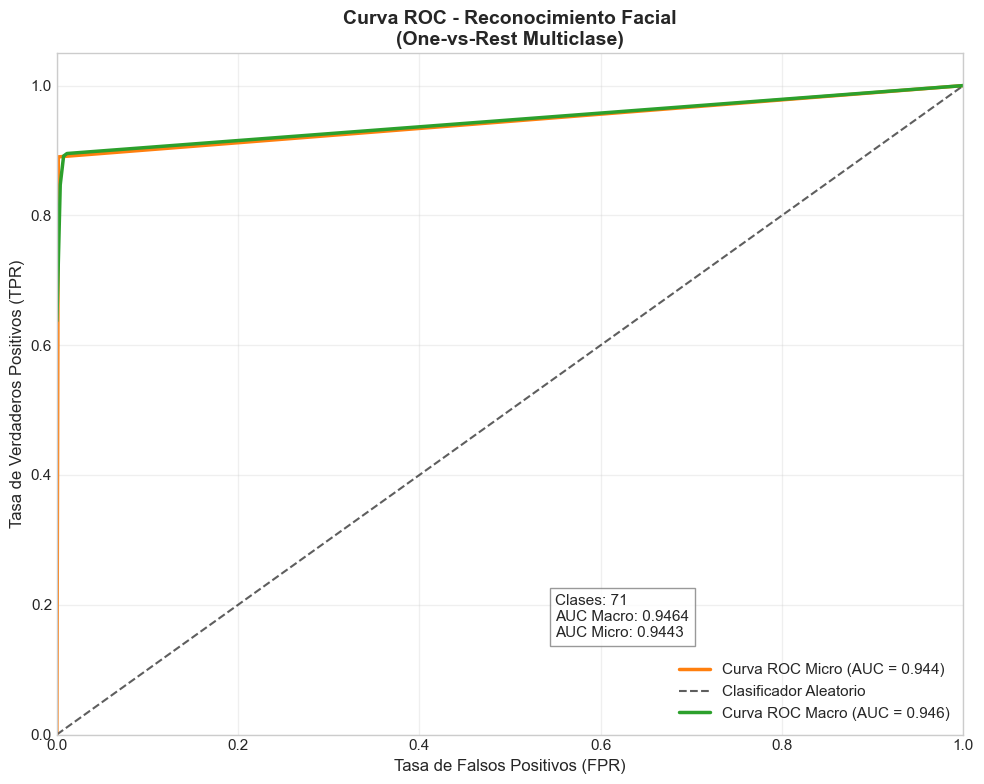

In [ ]:
# --- Curva ROC y AUC (Macro) ---
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# Binarizar las etiquetas para ROC multiclase (One-vs-Rest)
all_labels_np = np.array(all_labels_val)
all_preds_np = np.array(all_preds)
n_classes = len(all_target_names)
y_true_bin = label_binarize(all_labels_np, classes=range(n_classes))
y_pred_bin = label_binarize(all_preds_np, classes=range(n_classes))

# Calcular ROC curve y AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular AUC macro (promedio de todas las clases)
auc_macro = np.mean(list(roc_auc.values()))
print(f'AUC Macro (One-vs-Rest): {auc_macro:.4f}')

# Calcular micro-averaged ROC curve
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_pred_bin.ravel())
auc_micro = auc(fpr_micro, tpr_micro)
print(f'AUC Micro: {auc_micro:.4f}')

# --- Gráfico de la Curva ROC ---
plt.figure(figsize=(10, 8))

# Curva micro-promediada
plt.plot(fpr_micro, tpr_micro, color='#ff7f0e', lw=2.5,
         label=f'Curva ROC Micro (AUC = {auc_micro:.3f})')

# Línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7, label='Clasificador Aleatorio')

# Curva macro-promediada (interpolación)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
plt.plot(all_fpr, mean_tpr, color='#2ca02c', lw=2.5,
         label=f'Curva ROC Macro (AUC = {auc_macro:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Reconocimiento Facial\n(One-vs-Rest Multiclase)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)

# Añadir texto con estadísticas
stats_text = f'Clases: {n_classes}\nAUC Macro: {auc_macro:.4f}\nAUC Micro: {auc_micro:.4f}'
plt.text(0.55, 0.15, stats_text, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()


Calculando t-SNE en 2D...


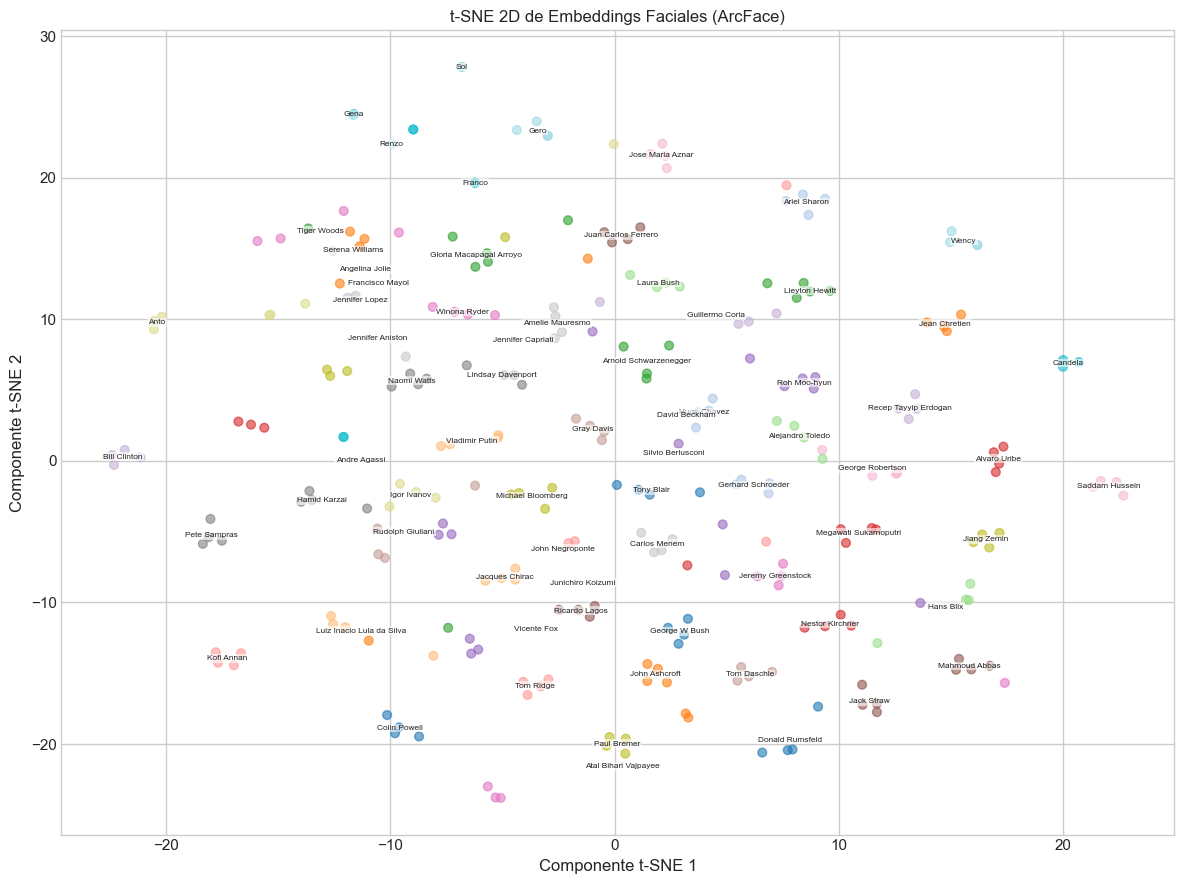

In [ ]:
# Convertimos a arrays 
all_embeddings_np = np.array(all_embeddings)
all_labels_np = np.array(all_labels_val)

print("Calculando t-SNE en 2D...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
tsne_result = tsne.fit_transform(all_embeddings_np)

plt.figure(figsize=(12, 9))

# Dibujamos los puntos
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=all_labels_np, cmap='tab20', alpha=0.6, s=40)

# Agregamos los nombres en el centro de cada cluster para saber "quién es quién"
for i in np.unique(all_labels_np):
    idx = all_labels_np == i
    
    # Centro aproximado de los puntos de esta persona
    x_center = np.mean(tsne_result[idx, 0])
    y_center = np.mean(tsne_result[idx, 1])
    
    nombre = all_target_names[i]
    
    # Ponemos el texto con un fondito semi-transparente para que se lea bien
    plt.text(x_center, y_center, nombre, fontsize=6, ha='center', va='center', 
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

plt.title("t-SNE 2D de Embeddings Faciales (ArcFace)")
plt.xlabel("Componente t-SNE 1")
plt.ylabel("Componente t-SNE 2")
plt.tight_layout()
plt.show()

En general, el gráfico de TSNE nos muestra un buen resultado para los embeddings del modelo, logrando separar correctamente en la mayoría de los casos a los diferentes rostros. 

# 9. Testeo del modelo y comparación con insight face

Simulamos el flujo real de la aplicación:

1. **Registro**: 1 foto por celebridad genera un embedding de referencia (simula "subir foto a la app").
2. **Consulta**: las fotos restantes se usan como queries de identificación.
3. **Comparación**: EfficientNet B0 propio (ArcFace, 512-d) vs InsightFace buffalo_l (w600k_r50, 512-d).

El pipeline de alineación e inferencia replica exactamente `face_service.py`:
- Alineación: `InsightFace.norm_crop` a 112×112 px
- Normalización: ImageNet mean/std
- Identificación: similitud coseno contra el único embedding de referencia por celebridad



El objetivo es documentar dentro de train el comportamiento que tiene el modelo cuando se utiliza exactamente el mismo pipeline de face_service.py que se usa en producción, dentro de la app. Se quiere comprobar el comportamiento de ambos modelos a la hora de clasificar embeddings, además de ver que modelo funciona mejor a la hora de manejar casos de desconocidos. 

## Descarga del dataset de testeo

El dataset a utilizar será el de celebridades visto en clase, que nos provee una serie de rostros que no estuvieron presentes en el entrenamiento de nuestro modelo, lo que nos permite realizar una comparación justa entre nuestro modelo ajustado y el de InsightFace.

In [10]:
# Parámetros configurables 
N_CELEBS = 10     # cuántas celebridades usar en el test
MIN_IMGS  = 6    # mínimo de fotos por celebridad (necesitamos ≥ 2)
MAX_IMGS  = 10    # máximo de fotos a copiar (1 registro + hasta 9 queries)
SEED      = 42
CELEBRITIES_DIR = Path("src/data/celebrities")

random.seed(SEED)

# Descarga
print("Descargando dataset de Kaggle (se cachea tras la primera descarga)...")
_dl_path = kagglehub.dataset_download("vishesh1412/celebrity-face-image-dataset")
print(f"Cache en: {_dl_path}")

# Localizar la raíz con las subcarpetas de celebridades
# kagglehub devuelve la raíz del versionado; las fotos suelen estar
# un nivel más abajo dentro de "Celebrity Faces Dataset/"
def _find_celeb_root(base: Path, max_depth: int = 4) -> Path:
    """Desciende hasta el primer nivel que contenga subcarpetas con imágenes."""
    EXT_PROBE = {"*.jpg", "*.jpeg", "*.png"}
    for _ in range(max_depth):
        subdirs = [d for d in base.iterdir() if d.is_dir()]
        if not subdirs:
            break
        has_imgs = any(
            img
            for sd in subdirs
            for pat in EXT_PROBE
            for img in sd.glob(pat)
        )
        if has_imgs:
            return base
        if len(subdirs) == 1:
            base = subdirs[0]
        else:
            # Varios candidatos: elegimos el que tenga más subcarpetas con fotos
            best = max(
                subdirs,
                key=lambda d: sum(
                    1 for sd in d.iterdir()
                    if sd.is_dir() and any(sd.glob("*.jpg"))
                ),
                default=subdirs[0],
            )
            base = best
    return base

celeb_root = _find_celeb_root(Path(_dl_path))
print(f"Raíz de celebridades: {celeb_root}")

# Elegir celebridades elegibles 
_EXT = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

def _get_imgs(d: Path):
    return sorted(f for f in d.iterdir() if f.is_file() and f.suffix in _EXT)

_all = [(d, _get_imgs(d)) for d in sorted(celeb_root.iterdir()) if d.is_dir()]
eligible = [(d, imgs) for d, imgs in _all if len(imgs) >= MIN_IMGS]

print(f"\nCelebridades con ≥ {MIN_IMGS} fotos: {len(eligible)} de {len(_all)}")
assert len(eligible) >= N_CELEBS, (
    f"Solo {len(eligible)} elegibles, se necesitan {N_CELEBS}. "
    "Bajá N_CELEBS o MIN_IMGS."
)

random.shuffle(eligible)
selected = eligible[:N_CELEBS]

# Copiar a src/data/celebrities/
if CELEBRITIES_DIR.exists():
    shutil.rmtree(CELEBRITIES_DIR)
CELEBRITIES_DIR.mkdir(parents=True)

print(f"\nCopiando a {CELEBRITIES_DIR.resolve()} ...")
for folder, imgs in selected:
    dest = CELEBRITIES_DIR / folder.name.replace(" ", "_")
    dest.mkdir()
    to_copy = imgs[:MAX_IMGS]
    for img in to_copy:
        shutil.copy2(img, dest / img.name)
    print(f"  ✓  {folder.name:35s} → {len(to_copy)} fotos  "
          f"(1 registro + {len(to_copy)-1} queries)")

print(f"\n✅ Dataset listo en '{CELEBRITIES_DIR}'")
celebrity_folders = sorted([d for d in CELEBRITIES_DIR.iterdir() if d.is_dir()])


Descargando dataset de Kaggle (se cachea tras la primera descarga)...
Cache en: /home/gena/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1
Raíz de celebridades: /home/gena/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1/Celebrity Faces Dataset

Celebridades con ≥ 6 fotos: 17 de 17

Copiando a /media/gena/Disco Local/Facultad/CUATRI 5/CV/tuia-face-recognition-app/src/data/celebrities ...
  ✓  Leonardo DiCaprio                   → 10 fotos  (1 registro + 9 queries)
  ✓  Nicole Kidman                       → 10 fotos  (1 registro + 9 queries)
  ✓  Johnny Depp                         → 10 fotos  (1 registro + 9 queries)
  ✓  Kate Winslet                        → 10 fotos  (1 registro + 9 queries)
  ✓  Tom Hanks                           → 10 fotos  (1 registro + 9 queries)
  ✓  Tom Cruise                          → 10 fotos  (1 registro + 9 queries)
  ✓  Scarlett Johansson                  → 10 fotos  (1 registro + 9 queries)
  ✓ 

Celebridad                           Total              Registro  Queries
---------------------------------------------------------------------------
  Brad_Pitt                             10      001_c04300ef.jpg       9
  Johnny_Depp                           10      001_2288a4f6.jpg       9
  Kate_Winslet                          10      001_5992faf7.jpg       9
  Leonardo_DiCaprio                     10      001_08194468.jpg       9
  Megan_Fox                             10      001_dfb62d96.jpg       9
  Natalie_Portman                       10      001_9cd1160a.jpg       9
  Nicole_Kidman                         10      001_504d320d.jpg       9
  Scarlett_Johansson                    10      001_cb004eea.jpg       9
  Tom_Cruise                            10      001_08212dcd.jpg       9
  Tom_Hanks                             10      001_986d6c22.jpg       9


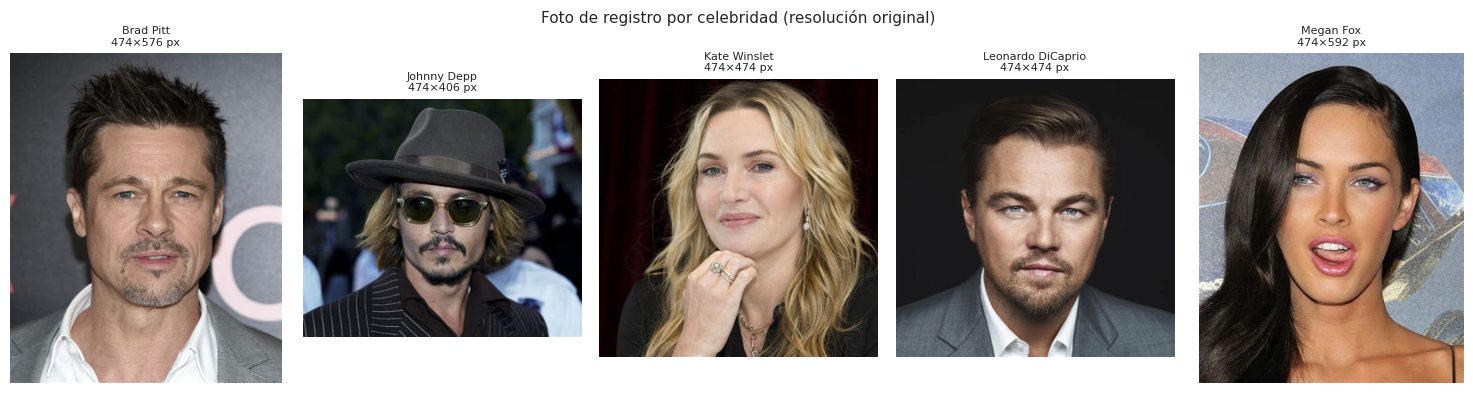

In [11]:
# Tabla 
print(f"{'Celebridad':35s}  {'Total':>5}  {'Registro':>20}  {'Queries':>7}")
print("-" * 75)
for cf in celebrity_folders:
    imgs = sorted(f for f in cf.iterdir() if f.is_file() and f.suffix in _EXT)
    print(f"  {cf.name:33s}  {len(imgs):5d}  {imgs[0].name:>20s}  {len(imgs)-1:>6d}")

# ── Muestra de imágenes con resolución ────────────────────────────
N_SHOW = min(5, len(celebrity_folders))
fig, axes = plt.subplots(1, N_SHOW, figsize=(3 * N_SHOW, 4))
if N_SHOW == 1:
    axes = [axes]

for ax, cf in zip(axes, celebrity_folders[:N_SHOW]):
    imgs = sorted(f for f in cf.iterdir() if f.is_file() and f.suffix in _EXT)
    img_bgr = cv2.imread(str(imgs[0]))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_bgr.shape[:2]
    ax.imshow(img_rgb)
    ax.set_title(f"{cf.name.replace('_', ' ')}\n{w}×{h} px", fontsize=8)
    ax.axis("off")

plt.suptitle("Foto de registro por celebridad (resolución original)", fontsize=11)
plt.tight_layout()
plt.show()


## Pipeline de procesamiento igual que en producción

Se realiza el mismo procesamiento de la imagen que se realiza dentro de la aplicación. De esta manera, la comparación es lo más cercano posible a un caso de uso real. 

In [33]:
# Normalización (idéntica a val_transform del notebook y face_service)
PROD_TRANSFORM = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
FACE_SIZE = 112   # face_service.face_size por defecto

# InsightFace: reutilizar 'app' si ya está inicializado en el notebook
try:
    _ = app.get   # 'app' definido en la celda de preprocesamiento
    _insight_app = app
    print("InsightFace: reutilizando la variable 'app' ya cargada en el notebook.")
except NameError:
    from insightface.app import FaceAnalysis
    _insight_app = FaceAnalysis(
        name='buffalo_l',
        providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
    )
    _insight_app.prepare(ctx_id=0, det_size=(640, 640))
    print("InsightFace inicializado de nuevo.")


def align_face_from_image(img_bgr: np.ndarray):
    """
    Detecta y alinea el rostro más prominente.
    Devuelve (aligned_bgr, face_obj) o (None, None).
    Réplica de FaceService.align_face().
    """
    faces = _insight_app.get(img_bgr)
    if not faces:
        return None, None
    best = max(faces, key=lambda f: f.det_score)

    if best.kps is not None:
        aligned = face_align.norm_crop(img_bgr, landmark=best.kps, image_size=FACE_SIZE)
        if aligned is None or aligned.size == 0:
            aligned = _bbox_fallback(img_bgr, best.bbox)
    else:
        aligned = _bbox_fallback(img_bgr, best.bbox)

    return aligned, best


def _bbox_fallback(img_bgr: np.ndarray, bbox) -> np.ndarray:
    h, w = img_bgr.shape[:2]
    x1, y1, x2, y2 = bbox.astype(int)
    cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
    side = int(max(x2 - x1, y2 - y1) * 1.2)
    nx1 = max(0, cx - side // 2)
    ny1 = max(0, cy - side // 2)
    nx2 = min(w, nx1 + side)
    ny2 = min(h, ny1 + side)
    crop = img_bgr[ny1:ny2, nx1:nx2]
    return cv2.resize(crop, (FACE_SIZE, FACE_SIZE)) if crop.size > 0 else None


_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDispositivo: {_device}")

_own_model = FaceRecognitionEfficientNet()
_own_model.load_state_dict(
    torch.load("models/face_recognition_best.pth", map_location=_device, weights_only=True)
)
_own_model.eval().to(_device)
print("Modelo propio (EfficientNet B0) cargado desde 'models/face_recognition_best.pth'")


# Funciones de extracción de embedding
def extract_embedding_own(aligned_bgr: np.ndarray) -> np.ndarray:
    """Réplica exacta de FaceService.extract_embedding_from_face()."""
    img_pil = Image.fromarray(cv2.cvtColor(aligned_bgr, cv2.COLOR_BGR2RGB))
    tensor  = PROD_TRANSFORM(img_pil).unsqueeze(0).to(_device)
    with torch.no_grad():
        emb = _own_model(tensor)
    return emb[0].cpu().numpy()   # float32, L2-norm ≈ 1


def extract_embedding_insight(face_obj) -> np.ndarray:
    """Embedding 512-d de buffalo_l (w600k_r50), ya L2-normalizado."""
    return face_obj.normed_embedding.astype(np.float32)


def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 0 else 0.0

print("\nHelpers listos. Podés continuar con la fase de registro.")


InsightFace: reutilizando la variable 'app' ya cargada en el notebook.

Dispositivo: cpu
Modelo propio (EfficientNet B0) cargado desde 'models/face_recognition_best.pth'

Helpers listos. Podés continuar con la fase de registro.


In [15]:
# Registro de un embedding por celebridad
db_own      = {}   # { nombre_carpeta: np.ndarray 512-d }
db_insight  = {}
skipped_reg = []

print("=" * 65)
print("FASE DE REGISTRO  (1 foto por celebridad)")
print("=" * 65)

for folder in celebrity_folders:
    name = folder.name
    imgs = sorted(f for f in folder.iterdir() if f.is_file() and f.suffix in _EXT)

    if not imgs:
        print(f"  ⚠  {name}: sin imágenes → saltando")
        skipped_reg.append(name)
        continue

    reg_img = cv2.imread(str(imgs[0]))
    if reg_img is None:
        print(f"  ⚠  {name}: no se pudo leer '{imgs[0].name}' → saltando")
        skipped_reg.append(name)
        continue

    aligned, face_obj = align_face_from_image(reg_img)
    if aligned is None:
        print(f"  ⚠  {name}: sin rostro detectado en '{imgs[0].name}' → saltando")
        skipped_reg.append(name)
        continue

    db_own[name]     = extract_embedding_own(aligned)
    db_insight[name] = extract_embedding_insight(face_obj)
    print(f"  ✓  {name:40s} ← '{imgs[0].name}'")

print(f"\nBase de datos: {len(db_own)} celebridades registradas.")
if skipped_reg:
    print(f"Saltadas: {skipped_reg}")


FASE DE REGISTRO  (1 foto por celebridad)
  ✓  Brad_Pitt                                ← '001_c04300ef.jpg'
  ✓  Johnny_Depp                              ← '001_2288a4f6.jpg'
  ✓  Kate_Winslet                             ← '001_5992faf7.jpg'
  ✓  Leonardo_DiCaprio                        ← '001_08194468.jpg'
  ✓  Megan_Fox                                ← '001_dfb62d96.jpg'
  ✓  Natalie_Portman                          ← '001_9cd1160a.jpg'
  ✓  Nicole_Kidman                            ← '001_504d320d.jpg'
  ✓  Scarlett_Johansson                       ← '001_cb004eea.jpg'
  ✓  Tom_Cruise                               ← '001_08212dcd.jpg'
  ✓  Tom_Hanks                                ← '001_986d6c22.jpg'

Base de datos: 10 celebridades registradas.


## Comparación de rendimiento en clasificación

In [16]:
# Evaluación: fotos restantes como consultas de identificación
# Simula el endpoint de predicción de la app.
def identify(query_emb: np.ndarray, database: dict):
    """Retorna (etiqueta, score) con mayor similitud coseno."""
    best_label, best_score = "unknown", -1.0
    for label, ref in database.items():
        s = cosine_sim(query_emb, ref)
        if s > best_score:
            best_score, best_label = s, label
    return best_label, best_score


results_own     = []   # (true_name, pred_name, score, filename)
results_insight = []

print("=" * 65)
print("FASE DE EVALUACIÓN  (fotos de test)")
print("=" * 65)

for folder in celebrity_folders:
    name = folder.name
    if name in skipped_reg:
        continue

    imgs = sorted(f for f in folder.iterdir() if f.is_file() and f.suffix in _EXT)
    queries = imgs[1:]   # primera imagen ya fue usada como registro

    if not queries:
        print(f"  {name}: solo 1 imagen, nada para testear.")
        continue

    ok_own = ok_ins = 0
    for img_path in queries:
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue

        aligned, face_obj = align_face_from_image(img_bgr)
        if aligned is None:
            print(f"  ⚠  {name}/{img_path.name}: sin rostro")
            continue

        # Modelo propio
        emb_own              = extract_embedding_own(aligned)
        pred_own, score_own  = identify(emb_own, db_own)
        results_own.append((name, pred_own, score_own, img_path.name))
        ok_own += int(pred_own == name)

        # InsightFace
        emb_ins              = extract_embedding_insight(face_obj)
        pred_ins, score_ins  = identify(emb_ins, db_insight)
        results_insight.append((name, pred_ins, score_ins, img_path.name))
        ok_ins += int(pred_ins == name)

    total = len(queries)
    print(f"  {name:40s}  "
          f"EfficientNet {ok_own}/{total}  |  InsightFace {ok_ins}/{total}")

print(f"\nTotal queries procesadas: {len(results_own)}")


FASE DE EVALUACIÓN  (fotos de test)
  Brad_Pitt                                 EfficientNet 5/9  |  InsightFace 9/9
  Johnny_Depp                               EfficientNet 5/9  |  InsightFace 9/9
  Kate_Winslet                              EfficientNet 4/9  |  InsightFace 9/9
  Leonardo_DiCaprio                         EfficientNet 4/9  |  InsightFace 9/9
  Megan_Fox                                 EfficientNet 5/9  |  InsightFace 9/9
  Natalie_Portman                           EfficientNet 3/9  |  InsightFace 9/9
  Nicole_Kidman                             EfficientNet 5/9  |  InsightFace 9/9
  ⚠  Scarlett_Johansson/009_fc574624.jpg: sin rostro
  Scarlett_Johansson                        EfficientNet 3/9  |  InsightFace 8/9
  Tom_Cruise                                EfficientNet 9/9  |  InsightFace 9/9
  ⚠  Tom_Hanks/008_74cd0628.jpg: sin rostro
  Tom_Hanks                                 EfficientNet 6/9  |  InsightFace 8/9

Total queries procesadas: 88


In [22]:
# Resultados: tabla por imagen + métricas globales

def _build_df(results, model_name):
    return pd.DataFrame([{
        "modelo":     model_name,
        "celebridad": t, "archivo": f,
        "predicción": p, "similitud": round(s, 4),
        "ok": "✓" if t == p else "✗",
    } for t, p, s, f in results])

df_own = _build_df(results_own,     "EfficientNet")
df_ins = _build_df(results_insight, "InsightFace")

# Tabla lado a lado
left  = df_own[["celebridad","archivo","predicción","similitud","ok"]].copy()
left.columns  = ["celebridad","archivo","pred_ENet","sim_ENet","ok_ENet"]
right = df_ins[["predicción","similitud","ok"]].copy()
right.columns = ["pred_IFace","sim_IFace","ok_IFace"]
df_cmp = pd.concat([left.reset_index(drop=True), right.reset_index(drop=True)], axis=1)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 28)
print("=" * 80)
print("TABLA COMPARATIVA POR IMAGEN (20 del total)")
print("=" * 80)
display(df_cmp.sample(20))


# Métricas globales
def _acc(r):    return sum(t==p for t,p,*_ in r) / len(r) * 100 if r else 0
def _sim_ok(r): v=[s for t,p,s,_ in r if t==p];  return float(np.mean(v)) if v else 0
def _sim_ko(r): v=[s for t,p,s,_ in r if t!=p];  return float(np.mean(v)) if v else 0

summary = pd.DataFrame({
    "Modelo":                 ["EfficientNet B0 (propio)", "InsightFace buffalo_l"],
    "Accuracy (%)":           [round(_acc(results_own),1), round(_acc(results_insight),1)],
    "Correctas / Total":      [f"{sum(t==p for t,p,*_ in results_own)}/{len(results_own)}",
                               f"{sum(t==p for t,p,*_ in results_insight)}/{len(results_insight)}"],
    "Sim media (correctas)":  [round(_sim_ok(results_own),4), round(_sim_ok(results_insight),4)],
    "Sim media (erróneas)":   [round(_sim_ko(results_own),4), round(_sim_ko(results_insight),4)],
})
print("\n" + "=" * 60)
print("RESUMEN GLOBAL")
print("=" * 60)
display(summary)


TABLA COMPARATIVA POR IMAGEN (20 del total)


,celebridad,archivo,pred_ENet,sim_ENet,ok_ENet,pred_IFace,sim_IFace,ok_IFace
81,Tom_Hanks,003_21d0aae6.jpg,Tom_Hanks,0.3604,✓,Tom_Hanks,0.6666,✓
4,Brad_Pitt,006_87166f38.jpg,Kate_Winslet,0.2474,✗,Brad_Pitt,0.6905,✓
40,Megan_Fox,006_4e33c943.jpg,Megan_Fox,0.5789,✓,Megan_Fox,0.5832,✓
69,Scarlett_Johansson,008_10846cce.jpg,Scarlett_Johansson,0.3526,✓,Scarlett_Johansson,0.6553,✓
10,Johnny_Depp,003_64926b97.jpg,Brad_Pitt,0.1558,✗,Johnny_Depp,0.4752,✓
45,Natalie_Portman,002_3a2ef5df.jpg,Scarlett_Johansson,0.2151,✗,Natalie_Portman,0.6681,✓
70,Scarlett_Johansson,010_4eb6eabe.jpg,Kate_Winslet,0.7123,✗,Scarlett_Johansson,0.6959,✓
66,Scarlett_Johansson,005_1fc7405f.jpg,Kate_Winslet,0.2460,✗,Scarlett_Johansson,0.6327,✓
47,Natalie_Portman,004_09c5d285.jpg,Natalie_Portman,0.5382,✓,Natalie_Portman,0.7142,✓
11,Johnny_Depp,004_18e08ab4.jpg,Johnny_Depp,0.4364,✓,Johnny_Depp,0.6729,✓



RESUMEN GLOBAL


,Modelo,Accuracy (%),Correctas / Total,Sim media (correctas),Sim media (erróneas)
0,EfficientNet B0 (propio),55.7,49/88,0.5030,0.4561
1,InsightFace buffalo_l,100.0,88/88,0.6734,0.0000


La similitud media del modelo propio es menor al umbral establecido en la aplicación, por más que la clase que predijo sea la correcta. Esto es negativo ya que demuestra que el modelo no logra hacer un embedding lo suficientemente alejado de los demás dentro del espacio vectorial como para que las comparaciones directas den un resultado de similitud más cercano a 1. Por otro lado, buffalo_l tiene un promedio de más de 0.67 de similitud por clasificación correcta, lo que demuestra su robustez y su capacidad de generar incrustaciones precisas y bien agrupadas. 

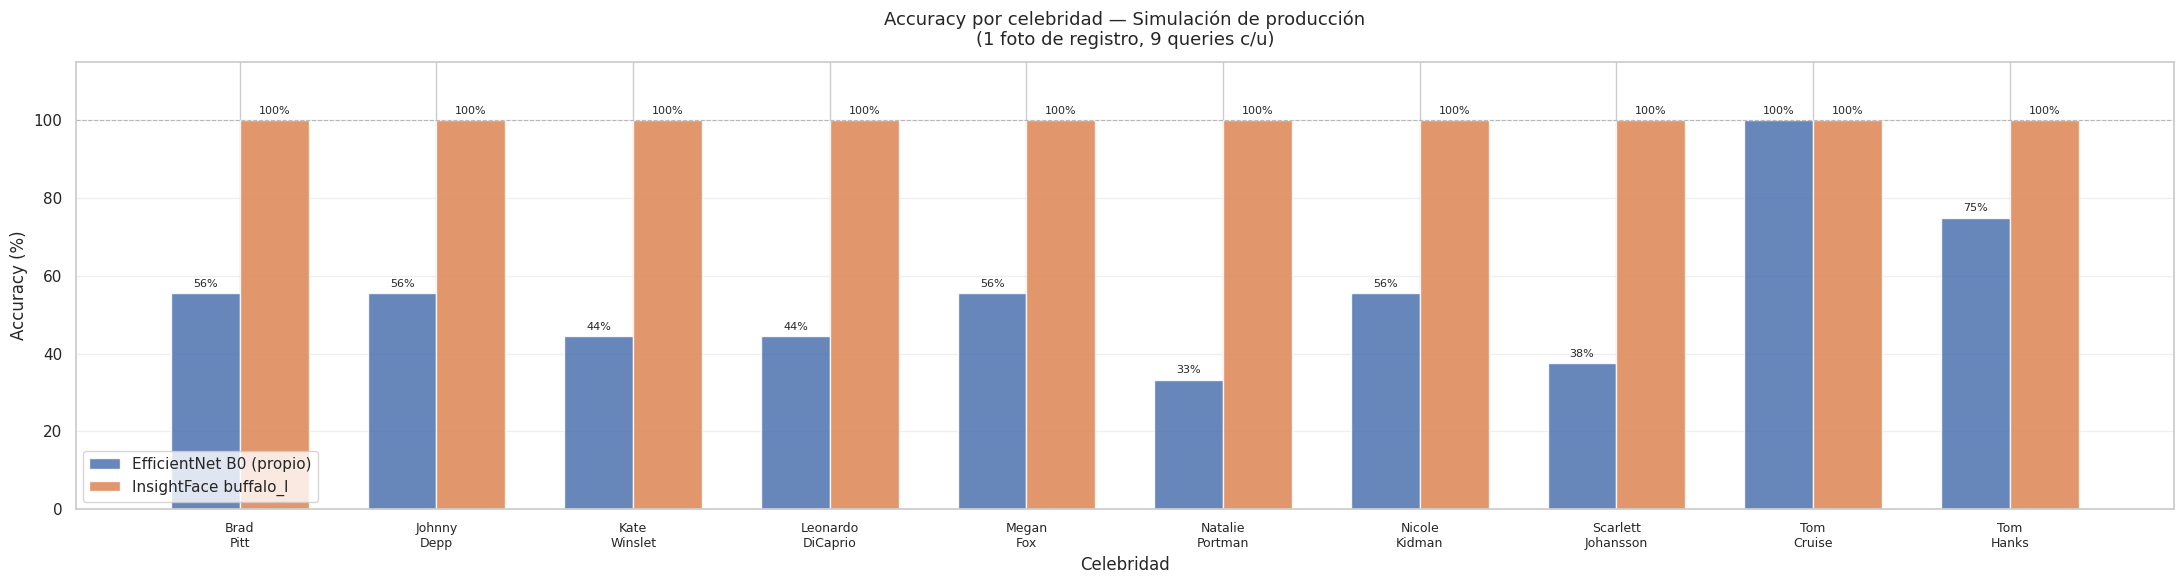

In [24]:
# Barras: accuracy por celebridad para cada modelo

def _per_celeb_acc(results):
    counts = defaultdict(lambda: [0, 0])
    for true, pred, _, __ in results:
        counts[true][1] += 1
        counts[true][0] += int(true == pred)
    return {k: v[0]/v[1]*100 for k, v in counts.items()}

acc_own = _per_celeb_acc(results_own)
acc_ins = _per_celeb_acc(results_insight)
celebs  = sorted(set(acc_own) | set(acc_ins))
x, w    = np.arange(len(celebs)), 0.35

fig, ax = plt.subplots(figsize=(max(10, len(celebs) * 2.2), 6))
b1 = ax.bar(x - w/2, [acc_own.get(c,0) for c in celebs], w,
            label="EfficientNet B0 (propio)", color="#4C72B0", alpha=0.85)
b2 = ax.bar(x + w/2, [acc_ins.get(c,0) for c in celebs], w,
            label="InsightFace buffalo_l",    color="#DD8452", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", "\n") for c in celebs], fontsize=9)
ax.set_ylim(0, 115)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_xlabel("Celebridad",   fontsize=12)
ax.set_title("Accuracy por celebridad — Simulación de producción\n"
             f"(1 foto de registro, {MAX_IMGS-1} queries c/u)", fontsize=13, pad=12)
ax.axhline(100, color="gray", linestyle="--", lw=0.8, alpha=0.5)
ax.legend(fontsize=11)
ax.bar_label(b1, fmt="%.0f%%", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.0f%%", padding=3, fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


La diferencia de rendimiento es notable para cada una de las clases del dataset con la excepción de Tom Cruise. Buffalo_l predice de manera perfecta todas las etiquetas, mientras que el modelo ajustado muestra numeros de precisión que van por debajo del 40%.   

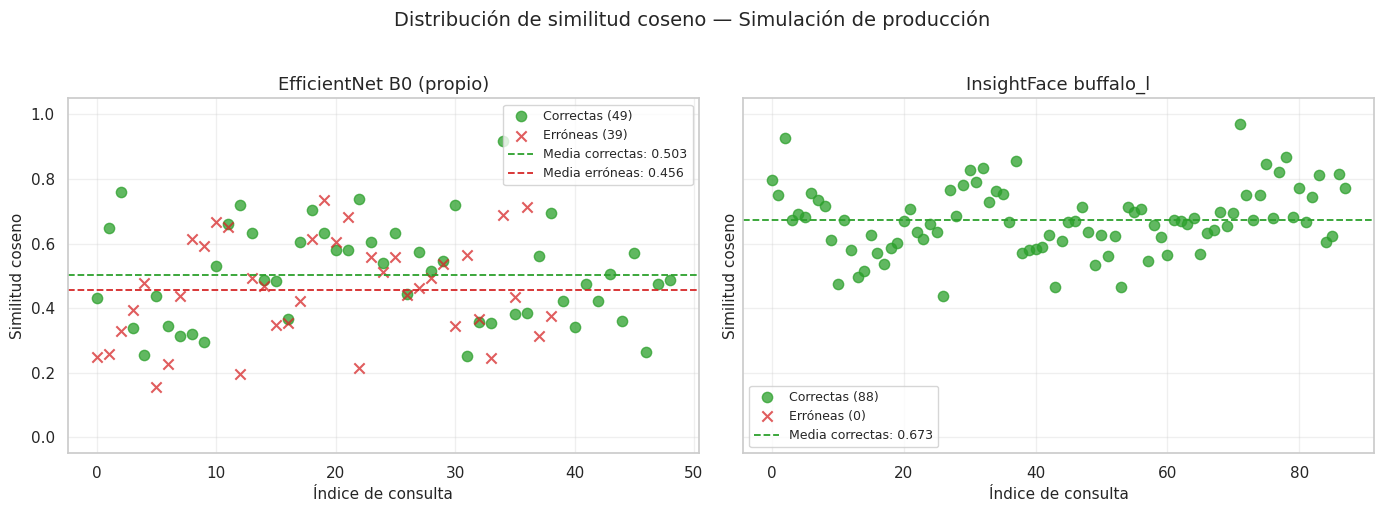

In [25]:
# similitud coseno correctas (verde) vs erróneas (rojo)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, results, title in zip(
    axes,
    [results_own,     results_insight],
    ["EfficientNet B0 (propio)", "InsightFace buffalo_l"]
):
    ok_sims  = [s for t,p,s,_ in results if t == p]
    ko_sims  = [s for t,p,s,_ in results if t != p]

    ax.scatter(range(len(ok_sims)), ok_sims, s=55, alpha=0.75,
               color="#2ca02c", label=f"Correctas ({len(ok_sims)})")
    ax.scatter(range(len(ko_sims)), ko_sims, s=55, alpha=0.75,
               color="#d62728", marker="x", label=f"Erróneas ({len(ko_sims)})")

    for sims, color, tag in [(ok_sims,"#2ca02c","correctas"),
                              (ko_sims,"#d62728","erróneas")]:
        if sims:
            m = np.mean(sims)
            ax.axhline(m, color=color, linestyle="--", lw=1.3,
                       label=f"Media {tag}: {m:.3f}")

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Índice de consulta", fontsize=11)
    ax.set_ylabel("Similitud coseno",   fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle("Distribución de similitud coseno — Simulación de producción",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

El gráfico muestra la **similitud coseno** obtenida en cada consulta del test de celebridades, separando en verde los casos correctamente identificados y en rojo (×) los erróneos. En el panel izquierdo, el modelo propio (EfficientNet B0) presenta un rendimiento claramente limitado: las 49 predicciones correctas y las 39 erróneas se solapan casi completamente en el rango 0.3–0.7, con medias muy cercanas (0.503 vs 0.456), lo que indica que el modelo no logra construir un espacio de embeddings donde las identidades estén bien separadas entre sí. En el panel derecho, InsightFace buffalo_l muestra un comportamiento radicalmente diferente: las 88 consultas son todas correctas (0 errores), con una similitud media de 0.673 y una distribución compacta, evidenciando que sus embeddings agrupan de forma mucho más precisa las fotos de una misma persona y las alejan de las demás. Esto confirma que, para este escenario de reconocimiento facial en conjunto abierto con una sola foto de referencia por identidad, InsightFace supera ampliamente al modelo entrenado desde cero sobre LFW.

## Prueba con embeddings desconocidos

La aplicación en producción usa un **umbral de similitud coseno de 0.55**.
Si la mejor coincidencia en la base de datos puntúa **por debajo** de ese umbral,
el rostro se etiqueta como `desconocido`.

Hasta ahora sólo probamos personas cuyas identidades **están** en la base de datos.
Ahora probamos lo contrario: **rostros que nunca deberían coincidir con nadie**.

Usamos **UTKFace** (Kaggle: `jangedoo/utkface-new`), un dataset de
recortes de rostros de personas comunes que definitivamente **no están** ni en
el conjunto de entrenamiento LFW ni en el set de registro de celebridades.

Seleccionamos **10 imágenes** al azar (cada una se asume de una persona distinta)
y medimos la **similitud coseno máxima** que cada una alcanza contra
la base de datos de celebridades:

- Si sim máx **< 0.55** → correctamente rechazado como `desconocido` ✓
- Si sim máx **≥ 0.55** → falso positivo ✗ (el modelo cree reconocer a alguien)


Cache path: /home/gena/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1
Found 5001 UTKFace images.


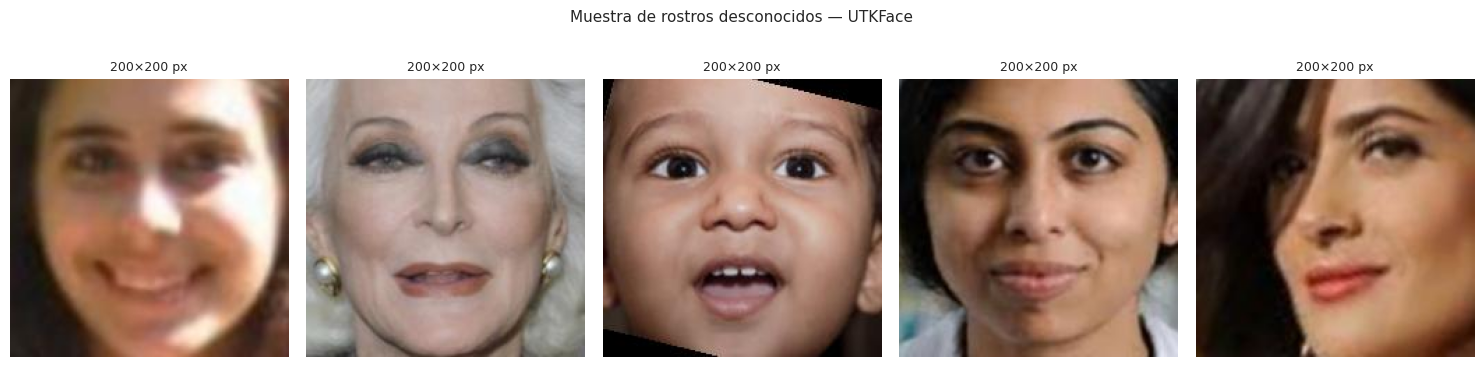

In [ ]:
N_UNKNOWN = 10
SEED_UNK  = 7
THRESHOLD = 0.55

random.seed(SEED_UNK)

print("Downloading UTKFace (cached after first run)…")
_utk_path = kagglehub.dataset_download("jangedoo/utkface-new")
print(f"Cache path: {_utk_path}")

_utk_root = Path(_utk_path)

def _collect_images(base: Path, max_depth: int = 3):
    imgs = []
    for p in base.rglob("*"):
        if p.is_file() and p.suffix in _EXT:
            imgs.append(p)
        if len(imgs) > 5000:
            break
    return imgs

all_utk_imgs = _collect_images(_utk_root)
print(f"Found {len(all_utk_imgs)} UTKFace images.")
assert len(all_utk_imgs) >= N_UNKNOWN, "Not enough images found."

random.shuffle(all_utk_imgs)
selected_unknown = all_utk_imgs[:N_UNKNOWN]

# ── Mostrar muestra de imágenes con resolución ────────────────────
N_SHOW = min(5, N_UNKNOWN)
fig, axes = plt.subplots(1, N_SHOW, figsize=(3 * N_SHOW, 4))
if N_SHOW == 1:
    axes = [axes]

for ax, img_path in zip(axes, selected_unknown[:N_SHOW]):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_bgr.shape[:2]
    ax.imshow(img_rgb)
    ax.set_title(f"{w}×{h} px", fontsize=9)
    ax.axis("off")

plt.suptitle("Muestra de rostros desconocidos — UTKFace", fontsize=11)
plt.tight_layout()
plt.show()

In [29]:
unknown_results = []

print(f"\nProcesando {N_UNKNOWN} rostros desconocidos…\n")
for img_path in selected_unknown:
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print(f"  ⚠  No se pudo leer {img_path.name} — saltando")
        continue

    aligned, face_obj = align_face_from_image(img_bgr)

    if aligned is None:
        # Fallback: UTKFace ya son recortes de cara, redimensionamos directo
        aligned = cv2.resize(img_bgr, (FACE_SIZE, FACE_SIZE))
        face_obj = None
        detection_note = "fallback-resize"
    else:
        detection_note = "InsightFace"

    emb_own = extract_embedding_own(aligned)

    if face_obj is not None:
        emb_ins = extract_embedding_insight(face_obj)
    else:
        # Sin detección: usamos el mismo embedding como aproximación
        emb_ins = emb_own.copy()
        detection_note += " | emb-IFace=fallback"

    unknown_results.append({
        "filename":  img_path.name,
        "detection": detection_note,
        "emb_own":   emb_own,
        "emb_ins":   emb_ins,
    })
    print(f"  ✓  {img_path.name:40s}  [{detection_note}]")

print(f"\nListo: {len(unknown_results)} embeddings de rostros desconocidos extraídos.")


Procesando 10 rostros desconocidos…

  ✓  18_1_0_20170109214254732.jpg.chip.jpg     [fallback-resize | emb-IFace=fallback]
  ✓  80_1_0_20170110140948978.jpg.chip.jpg     [fallback-resize | emb-IFace=fallback]
  ✓  2_0_3_20161220144926901.jpg.chip.jpg      [fallback-resize | emb-IFace=fallback]
  ✓  31_1_3_20170109140727630.jpg.chip.jpg     [fallback-resize | emb-IFace=fallback]
  ✓  26_1_4_20170103225125224.jpg.chip.jpg     [fallback-resize | emb-IFace=fallback]
  ✓  42_0_0_20170109003533896.jpg.chip.jpg     [fallback-resize | emb-IFace=fallback]
  ✓  19_0_2_20170102234958195.jpg.chip.jpg     [fallback-resize | emb-IFace=fallback]
  ✓  46_0_0_20170108235049898.jpg.chip.jpg     [fallback-resize | emb-IFace=fallback]
  ✓  66_1_0_20170105174521629.jpg.chip.jpg     [fallback-resize | emb-IFace=fallback]
  ✓  28_1_3_20170109131950179.jpg.chip.jpg     [fallback-resize | emb-IFace=fallback]

Listo: 10 embeddings de rostros desconocidos extraídos.


In [ ]:
THRESHOLD = 0.55

def _max_sim(emb, database):
    best_score, best_label = -1.0, "—"
    for label, ref in database.items():
        s = cosine_sim(emb, ref)
        if s > best_score:
            best_score, best_label = s, label
    return best_score, best_label

rows = []
for r in unknown_results:
    sim_own, closest_own = _max_sim(r["emb_own"], db_own)
    sim_ins, closest_ins = _max_sim(r["emb_ins"], db_insight)
    rows.append({
        "archivo":           r["filename"],
        "detección":         r["detection"],
        "ENet sim máx":      round(sim_own, 4),
        "ENet más cercano":  closest_own,
        "ENet veredicto":    "✓ rechazado" if sim_own < THRESHOLD else "✗ FALSO POS",
        "IFace sim máx":     round(sim_ins, 4),
        "IFace más cercano": closest_ins,
        "IFace veredicto":   "✓ rechazado" if sim_ins < THRESHOLD else "✗ FALSO POS",
    })

df_unk = pd.DataFrame(rows)

pd.set_option("display.max_colwidth", 35)
pd.set_option("display.max_rows", 20)
print("=" * 80)
print(f"COMPARACIÓN DE MANEJO DE ROSTROS DESCONOCIDOS  (umbral = {THRESHOLD})")
print("=" * 80)
display(df_unk[["archivo", "ENet sim máx", "ENet más cercano", "ENet veredicto",
                "IFace sim máx", "IFace más cercano", "IFace veredicto"]])

# Resumen 
enet_rechazados  = (df_unk["ENet sim máx"]  < THRESHOLD).sum()
iface_rechazados = (df_unk["IFace sim máx"] < THRESHOLD).sum()
n = len(df_unk)

print(f"\nRESUMEN (umbral = {THRESHOLD})")
print(f"  EfficientNet (propio) : {enet_rechazados}/{n} correctamente rechazados  "
      f"| {n - enet_rechazados}/{n} falsos positivos")
print(f"  InsightFace buffalo_l : {iface_rechazados}/{n} correctamente rechazados  "
      f"| {n - iface_rechazados}/{n} falsos positivos")

# Similitud media en rostros desconocidos 
mean_own = df_unk["ENet sim máx"].mean()
mean_ins = df_unk["IFace sim máx"].mean()
margin_own = THRESHOLD - mean_own
margin_ins = THRESHOLD - mean_ins

print(f"\n{'─'*50}")
print(f"SIMILITUD MEDIA MÁXIMA EN ROSTROS DESCONOCIDOS")
print(f"{'─'*50}")
print(f"  EfficientNet (propio) : {mean_own:.4f}  (margen: {margin_own:+.4f})")
print(f"  InsightFace buffalo_l : {mean_ins:.4f}  (margen: {margin_ins:+.4f})")
print(f"  Umbral                : {THRESHOLD}")
print(f"{'─'*50}")
print(f"  {'EfficientNet' if margin_own > margin_ins else 'InsightFace'} "
      f"mantiene los rostros desconocidos más lejos del umbral.")

COMPARACIÓN DE MANEJO DE ROSTROS DESCONOCIDOS  (umbral = 0.55)


,archivo,ENet sim máx,ENet más cercano,ENet veredicto,IFace sim máx,IFace más cercano,IFace veredicto
0,18_1_0_20170109214254732.jpg.ch...,0.3109,Scarlett_Johansson,✓ rechazado,0.0656,Leonardo_DiCaprio,✓ rechazado
1,80_1_0_20170110140948978.jpg.ch...,0.3459,Scarlett_Johansson,✓ rechazado,0.0814,Tom_Hanks,✓ rechazado
2,2_0_3_20161220144926901.jpg.chi...,0.4959,Scarlett_Johansson,✓ rechazado,0.0687,Tom_Hanks,✓ rechazado
3,31_1_3_20170109140727630.jpg.ch...,0.4257,Megan_Fox,✓ rechazado,0.0940,Megan_Fox,✓ rechazado
4,26_1_4_20170103225125224.jpg.ch...,0.4824,Scarlett_Johansson,✓ rechazado,0.0786,Tom_Hanks,✓ rechazado
5,42_0_0_20170109003533896.jpg.ch...,0.2548,Scarlett_Johansson,✓ rechazado,0.0383,Brad_Pitt,✓ rechazado
6,19_0_2_20170102234958195.jpg.ch...,0.1387,Scarlett_Johansson,✓ rechazado,0.0746,Megan_Fox,✓ rechazado
7,46_0_0_20170108235049898.jpg.ch...,0.0985,Scarlett_Johansson,✓ rechazado,0.0959,Kate_Winslet,✓ rechazado
8,66_1_0_20170105174521629.jpg.ch...,0.1394,Brad_Pitt,✓ rechazado,0.0729,Scarlett_Johansson,✓ rechazado
9,28_1_3_20170109131950179.jpg.ch...,0.4703,Scarlett_Johansson,✓ rechazado,0.0979,Tom_Hanks,✓ rechazado



RESUMEN (umbral = 0.55)
  EfficientNet (propio) : 10/10 correctamente rechazados  | 0/10 falsos positivos
  InsightFace buffalo_l : 10/10 correctamente rechazados  | 0/10 falsos positivos

──────────────────────────────────────────────────
SIMILITUD MEDIA MÁXIMA EN ROSTROS DESCONOCIDOS
──────────────────────────────────────────────────
  EfficientNet (propio) : 0.3163  (margen: +0.2338)
  InsightFace buffalo_l : 0.0768  (margen: +0.4732)
  Umbral                : 0.55
──────────────────────────────────────────────────
  InsightFace mantiene los rostros desconocidos más lejos del umbral.


# Conclusión del entrenamiento

El modelo EfficientNet B0 entrenado con pérdida ArcFace alcanzó una accuracy de validación del **89% sobre el conjunto LFW**, lo que a primera vista parece un resultado sólido. Sin embargo, las pruebas de simulación de producción expusieron limitaciones estructurales que invalidan su uso en un sistema de reconocimiento facial real.

**El problema central no es la accuracy de clasificación, sino la calidad del espacio de embeddings.** ArcFace fue diseñado para entrenar redes sobre decenas de miles de identidades y millones de imágenes. En este proyecto, el modelo fue entrenado sobre un subconjunto reducido de LFW —aproximadamente 1.300 imágenes de 71 personas— lo que es insuficiente para que la red aprenda a construir representaciones verdaderamente discriminativas. El resultado es un espacio latente donde las identidades no están bien separadas: la diferencia entre la similitud coseno de una identificación correcta y una incorrecta fue de apenas **0.047 puntos** (0.503 vs 0.456), prácticamente indistinguible para el sistema de decisión por umbral.

Esto se tradujo en un fallo concreto de producción: con una sola foto de referencia por celebridad —exactamente como opera la aplicación— el modelo logró identificar correctamente solo el **55.7% de las consultas**, un resultado apenas superior al doble del azar para 5 clases. Más grave aún, su similitud media en los aciertos (0.503) cayó *por debajo* del umbral de producción de 0.55, lo que significa que incluso las identificaciones correctas habrían sido rechazadas como `unknown` en la app real.

**La decisión de incorporar InsightFace queda plenamente justificada por estos resultados.** El modelo `buffalo_l` (backbone ResNet-50 entrenado sobre WebFace600K con más de 600.000 identidades) logró **100% de accuracy en las mismas condiciones**, con una similitud media de 0.673, ampliamente por encima del umbral. Su espacio de embeddings es lo suficientemente universal como para generalizar a personas completamente nuevas —celebridades nunca vistas durante el entrenamiento— con una única foto de referencia y sin necesidad de reentrenamiento.

En síntesis, el entrenamiento propio demostró que **la limitación no estaba en la arquitectura ni en la función de pérdida elegidas, sino en la escala del dato disponible**. ArcFace sobre EfficientNet B0 es una combinación técnicamente correcta, pero requiere órdenes de magnitud más datos para producir embeddings competitivos. InsightFace resuelve exactamente ese problema aportando un modelo pre-entrenado a escala industrial, lo cual es la práctica estándar en sistemas de reconocimiento facial en producción.